## Case Study: Data Visualization using Seaborn (Titanic Dataset)
    Business Problem

    -A shipping company wants to understand factors affecting passenger survival during the Titanic disaster. 
    -The goal is to identify patterns in survival based on demographics and ticket class.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

In [2]:

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Data Understanding

In [3]:
df.shape

(891, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df['sex'] = df['sex'].astype('category')
df['embarked'] = df['embarked'].astype('category')

In [8]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

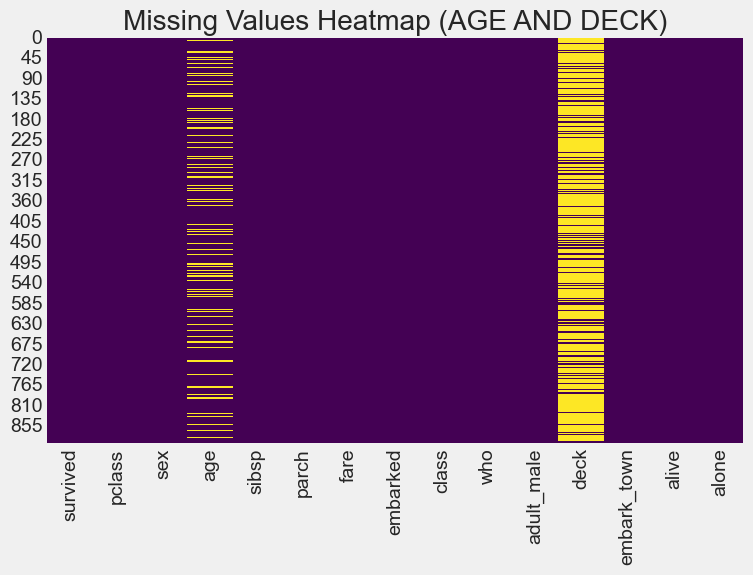

In [12]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap (AGE AND DECK)")
plt.show()

In [14]:
df['age'].dropna()

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
885    39.0
886    27.0
887    19.0
889    26.0
890    32.0
Name: age, Length: 714, dtype: float64

### Univariate Analysis
    Age Distribution

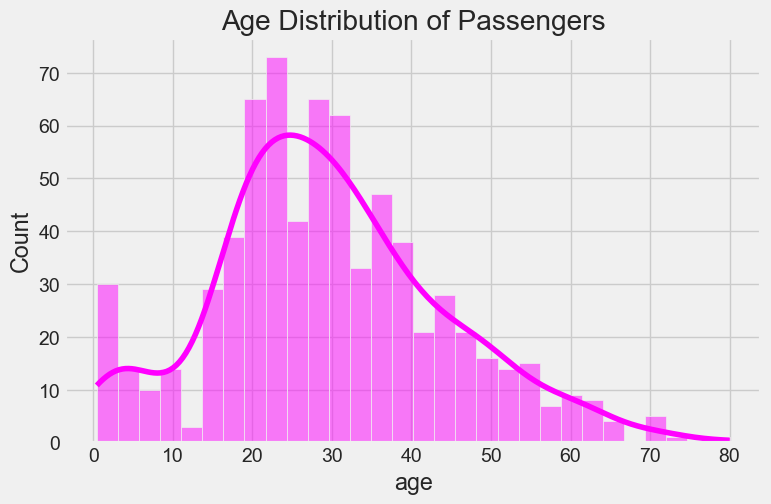

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'].dropna(), bins=30, kde=True,color='magenta')



plt.title("Age Distribution of Passengers")
plt.show()

### Passenger Class Distribution

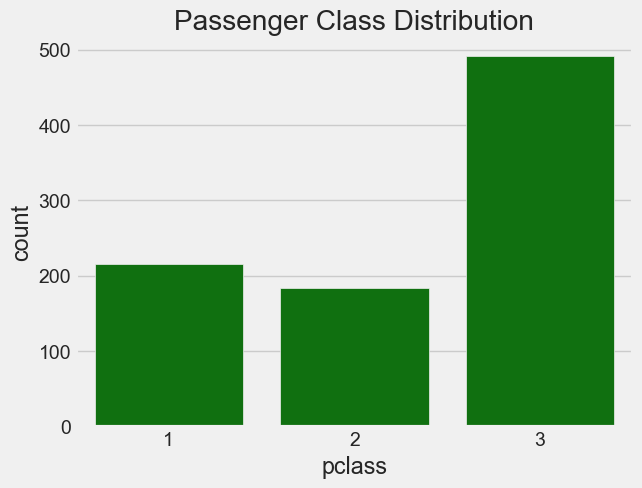

In [17]:
sns.countplot(x='pclass', data=df,color='green')
plt.title("Passenger Class Distribution")
plt.show()

### Bivariate Analysis
    Survival vs Gender

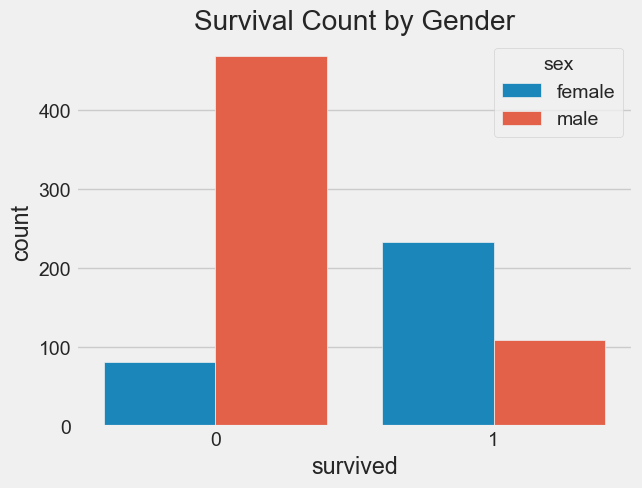

In [18]:
sns.countplot(x='survived', hue='sex', data=df)
plt.title("Survival Count by Gender")
plt.show()

### Multivariate Analysis
    Age vs Fare vs Survival

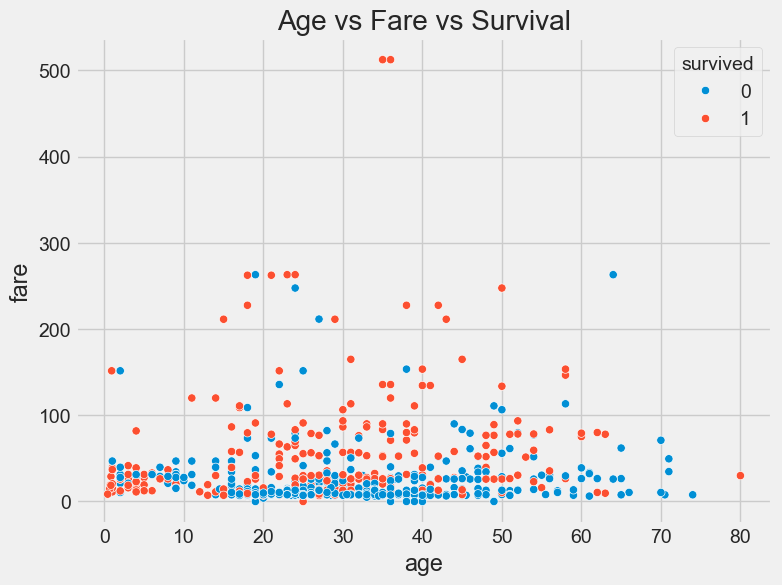

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='age', y='fare', hue='survived', data=df)
plt.title("Age vs Fare vs Survival")
plt.show()

### Correlation Heatmap

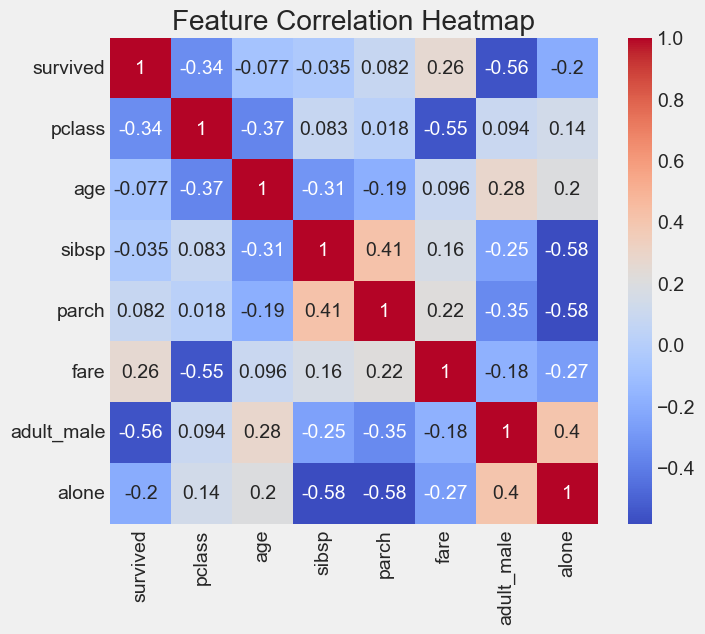

In [23]:

plt.figure(figsize=(7,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

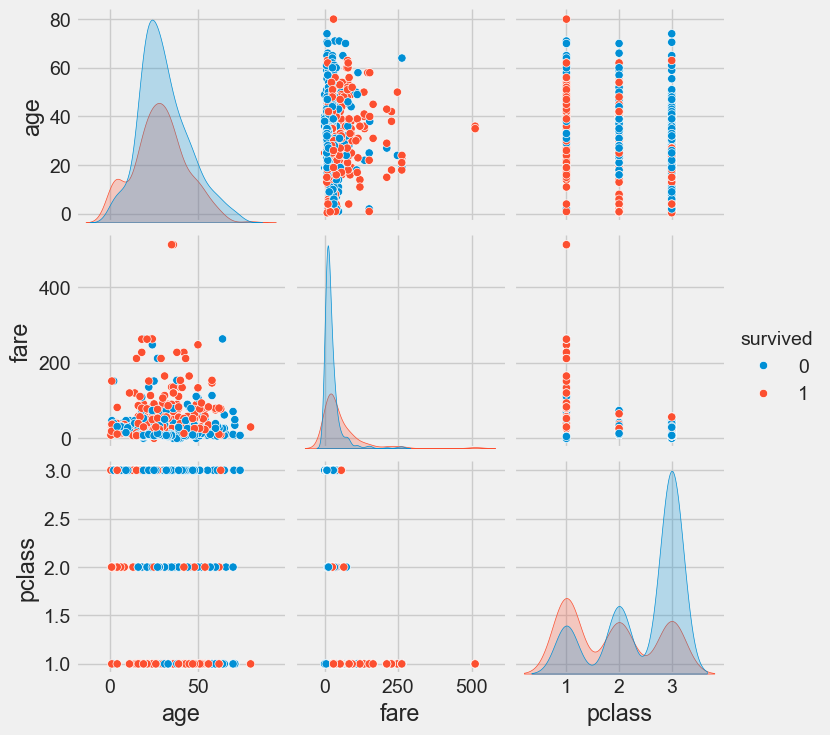

In [21]:
sns.pairplot(df[['survived','age','fare','pclass']].dropna(), hue='survived')
plt.show()

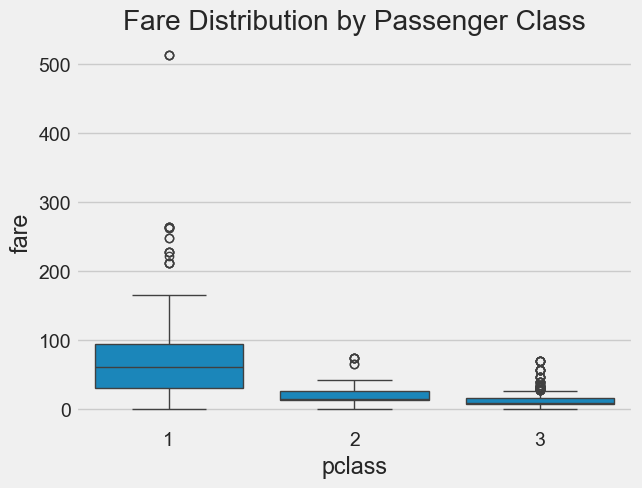

In [22]:
sns.boxplot(x='pclass', y='fare', data=df)
plt.title("Fare Distribution by Passenger Class")
plt.show()

### Did fare paid influence survival?

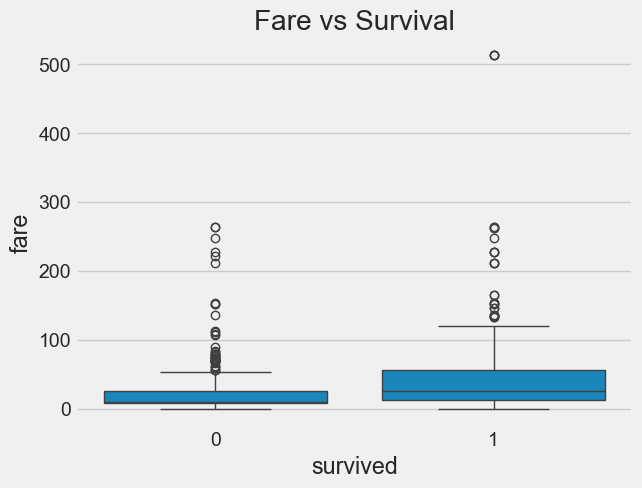

In [24]:
sns.boxplot(x="survived", y="fare", data=df)
plt.title("Fare vs Survival")
plt.show()

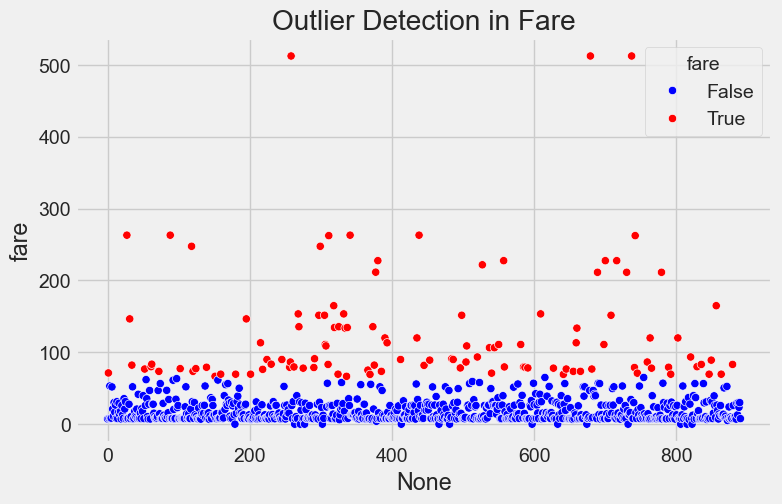

In [28]:
plt.figure(figsize=(8,5))

Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sns.scatterplot(
    x=df.index,
    y=df["fare"],
    hue=(df["fare"] > upper_bound),
    palette={True: "red", False: "blue"}
)

plt.title("Outlier Detection in Fare")
plt.show()

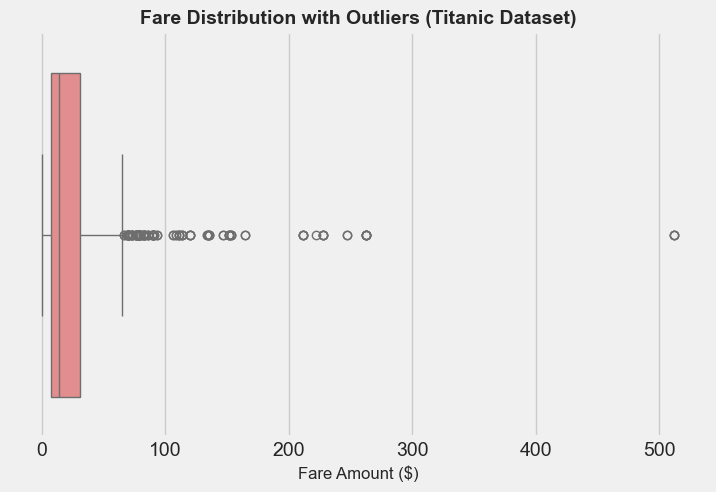

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["fare"],
    color="lightcoral"
)

plt.title("Fare Distribution with Outliers (Titanic Dataset)", fontsize=14, fontweight="bold")
plt.xlabel("Fare Amount ($)", fontsize=12)

plt.show()
